<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo deste exercício é explorar os modelos de Redes Neurais Artificiais (ANN - Artificial Neural Network) com Scikit-Learn em Python, sobre os dados da Lego**

Inteligência Artificial - ML com Scikit-learn



**Dupla**

| | Nome | Usuário no GitHub |
| --- | --- | --- |
| Integrante 1 | Daniel Teles de Oliveira | DanielTelesdeOlivera |
| Integrante 2 | João Victor Torres Soares | JTSoares |

### Dados (LEGO)

LEGO sets released from 1970 to 2022, including details on each set's theme, pieces, recommended age, retail price, and image.

https://mavenanalytics.io/data-playground/lego-sets


## TODO

- Baixar os dados
- Carregar em data frame Pandas
- Exibir visualmente os dados faltantes
- Organizar e limpar os dados
- Completar os kits de lego (Lego Sets) sem preço
   - Modelagem: Usando redes neurais artificial (ANN)
   - Scikit-learn
- Realizar análise e visualizações
   

Baixando dados do site, com o comando do Linux `wget` e o magic **!**

In [ ]:
!wget https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip

--2026-09-29 13:56:19--  https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip
Resolving maven-datasets.s3.amazonaws.com (maven-datasets.s3.amazonaws.com)... 16.15.236.214, 52.217.85.40, 16.15.207.247, ...
Connecting to maven-datasets.s3.amazonaws.com (maven-datasets.s3.amazonaws.com)|16.15.236.214|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 536301 (524K) [application/zip]
Saving to: ‘LEGO+Sets.zip’

LEGO+Sets.zip       100%[===================>] 523.73K   693KB/s    in 0.8s    

2026-09-29 13:56:20 (693 KB/s) - ‘LEGO+Sets.zip’ saved [536301/536301]



Descompactando arquivo zip

In [ ]:
!unzip *.zip

Archive:  LEGO+Sets.zip
  inflating: lego_sets.csv           
  inflating: lego_sets_data_dictionary.csv  


Listando os arquivos na pasta atual

In [ ]:
!ls -l

total 4380
-rw-r--r-- 1 root root 3936470 Jan  3  2024 lego_sets.csv
-rw-r--r-- 1 root root     532 Jan  3  2024 lego_sets_data_dictionary.csv
-rw-r--r-- 1 root root  536301 Jan  3  2024 LEGO+Sets.zip
drwxr-xr-x 1 root root    4096 Sep 16 13:26 sample_data


Importando LIBs de EDA (Exploratory Data Analisys)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


Carregando e visualizando dados

In [ ]:
lego_df = pd.read_csv('lego_sets.csv')

lego_df.head()

,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN


In [ ]:
lego_df["agerange_min"].unique()

array([nan,  6.,  3.,  1.,  5.,  9.,  7.,  8., 10., 11.,  2.,  4., 12.,
       14., 16., 18.])

In [ ]:
lego_df["US_retailPrice"].unique()

array([   nan,  12.99,  27.99,  41.99,  14.99,   4.99,   2.49,  23.99,
         6.99,   9.99,   5.99,   8.99,  19.99,   7.99, 269.99,  24.99,
       249.99,  22.99,  29.99,  49.99,  89.99,  59.99,  79.99,   3.99,
        69.99,  39.99, 139.99,   3.49,  60.  ,  15.99,  10.  ,  34.99,
        74.99,  99.99, 149.99, 119.99,  54.99, 169.99,  32.5 ,   2.99,
        15.  ,  11.99,  44.99,  30.  ,  16.99, 109.99,   1.99, 129.99,
       499.99, 199.99,  17.99,  17.  ,   7.49,   9.49, 174.95, 399.99,
       299.99,   1.49,  10.99,  17.48, 279.99,  26.99,   5.79,   6.49,
       199.95,  21.99, 179.99, 259.99, 239.99, 484.99,  36.99, 159.99,
        13.99,  18.99,  31.99, 319.99, 349.99, 219.99, 239.95, 224.95,
        99.95,  29.95,  39.95,  49.95,  24.95, 789.99, 754.99,  25.99,
        20.99,  32.99, 159.95,  64.99,  57.97, 174.99,  94.99,  47.94,
        84.99, 229.99,  34.95, 189.99,   2.48, 149.98,  94.95,  14.95,
       155.91, 369.99, 289.99, 209.95, 849.99, 379.99, 469.99,  26.5 ,
      

Buscando os valores faltantes (nulls)

In [ ]:
# show missing values
lego_df.isnull().sum()

,0
set_id,0
name,0
year,0
theme,0
subtheme,3556
themeGroup,2
category,0
pieces,3924
minifigs,10058
agerange_min,11670


Visualizando valores faltantes (nulls)

<Axes: >

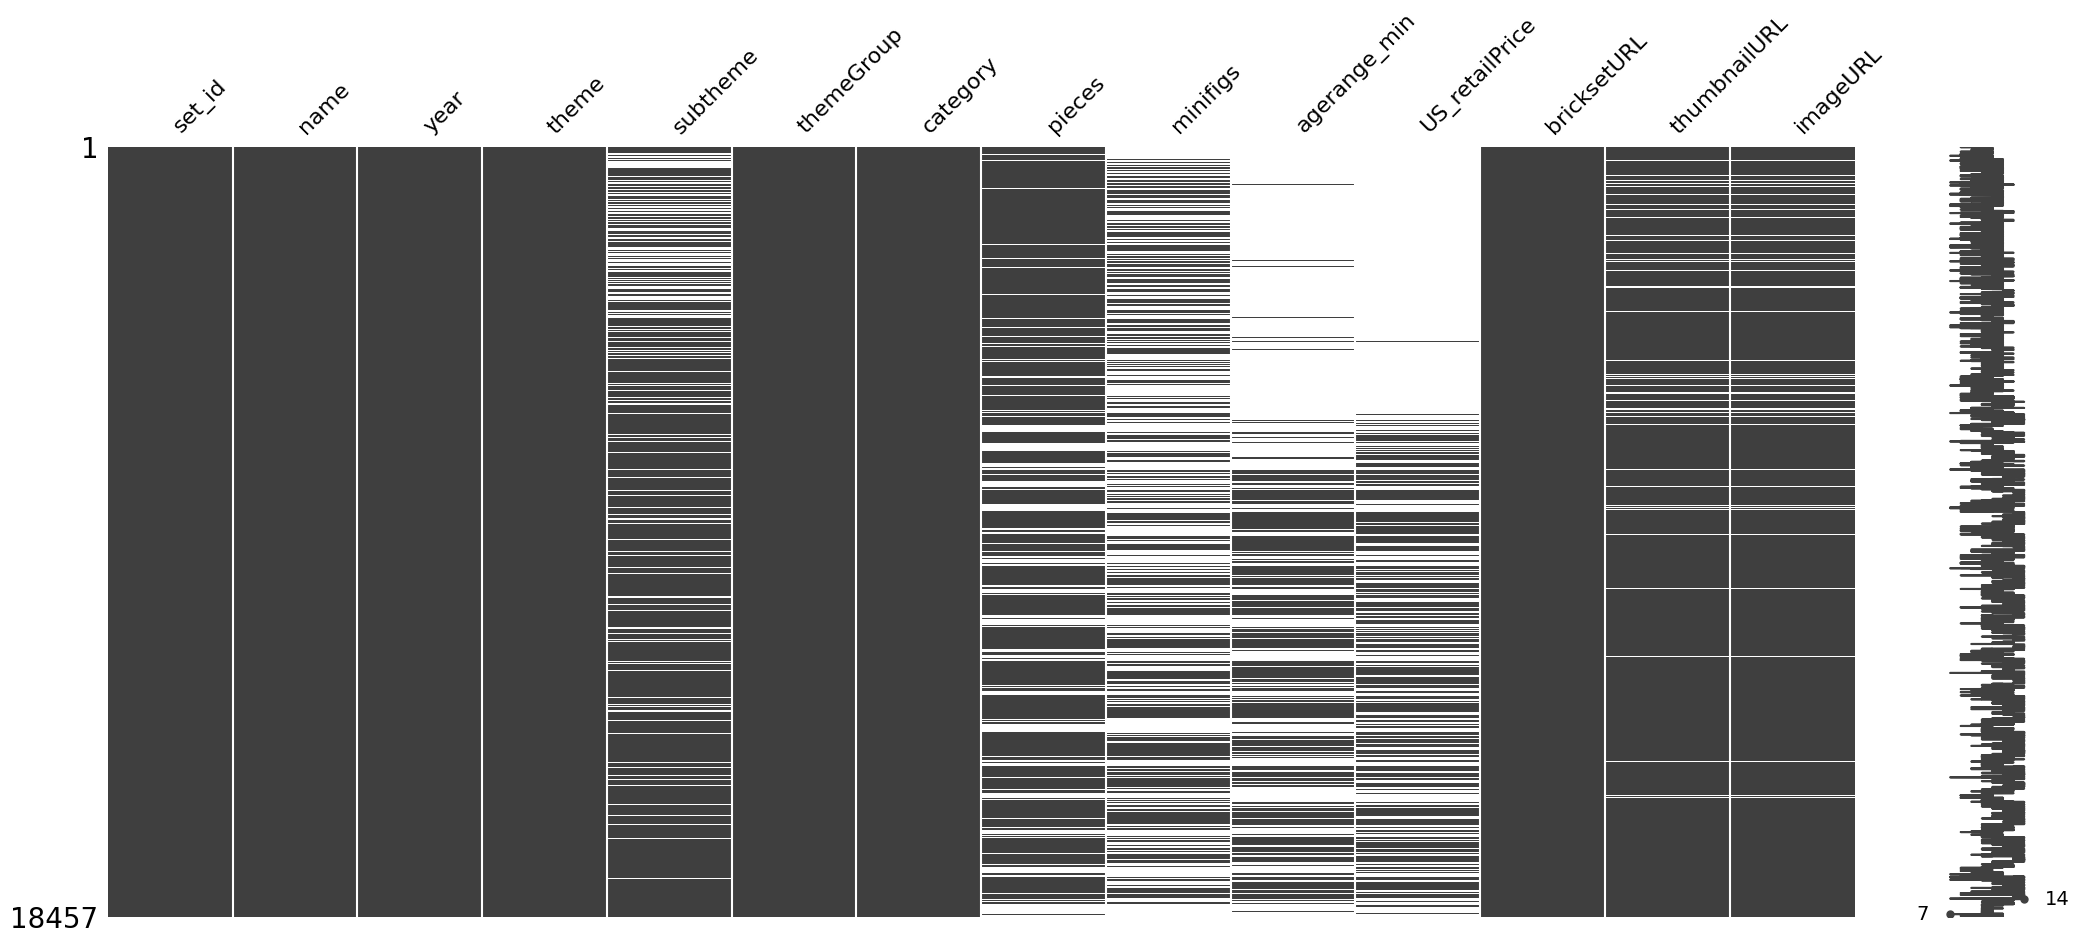

In [ ]:
#Visualize missing values
msno.matrix(lego_df)


<Axes: >

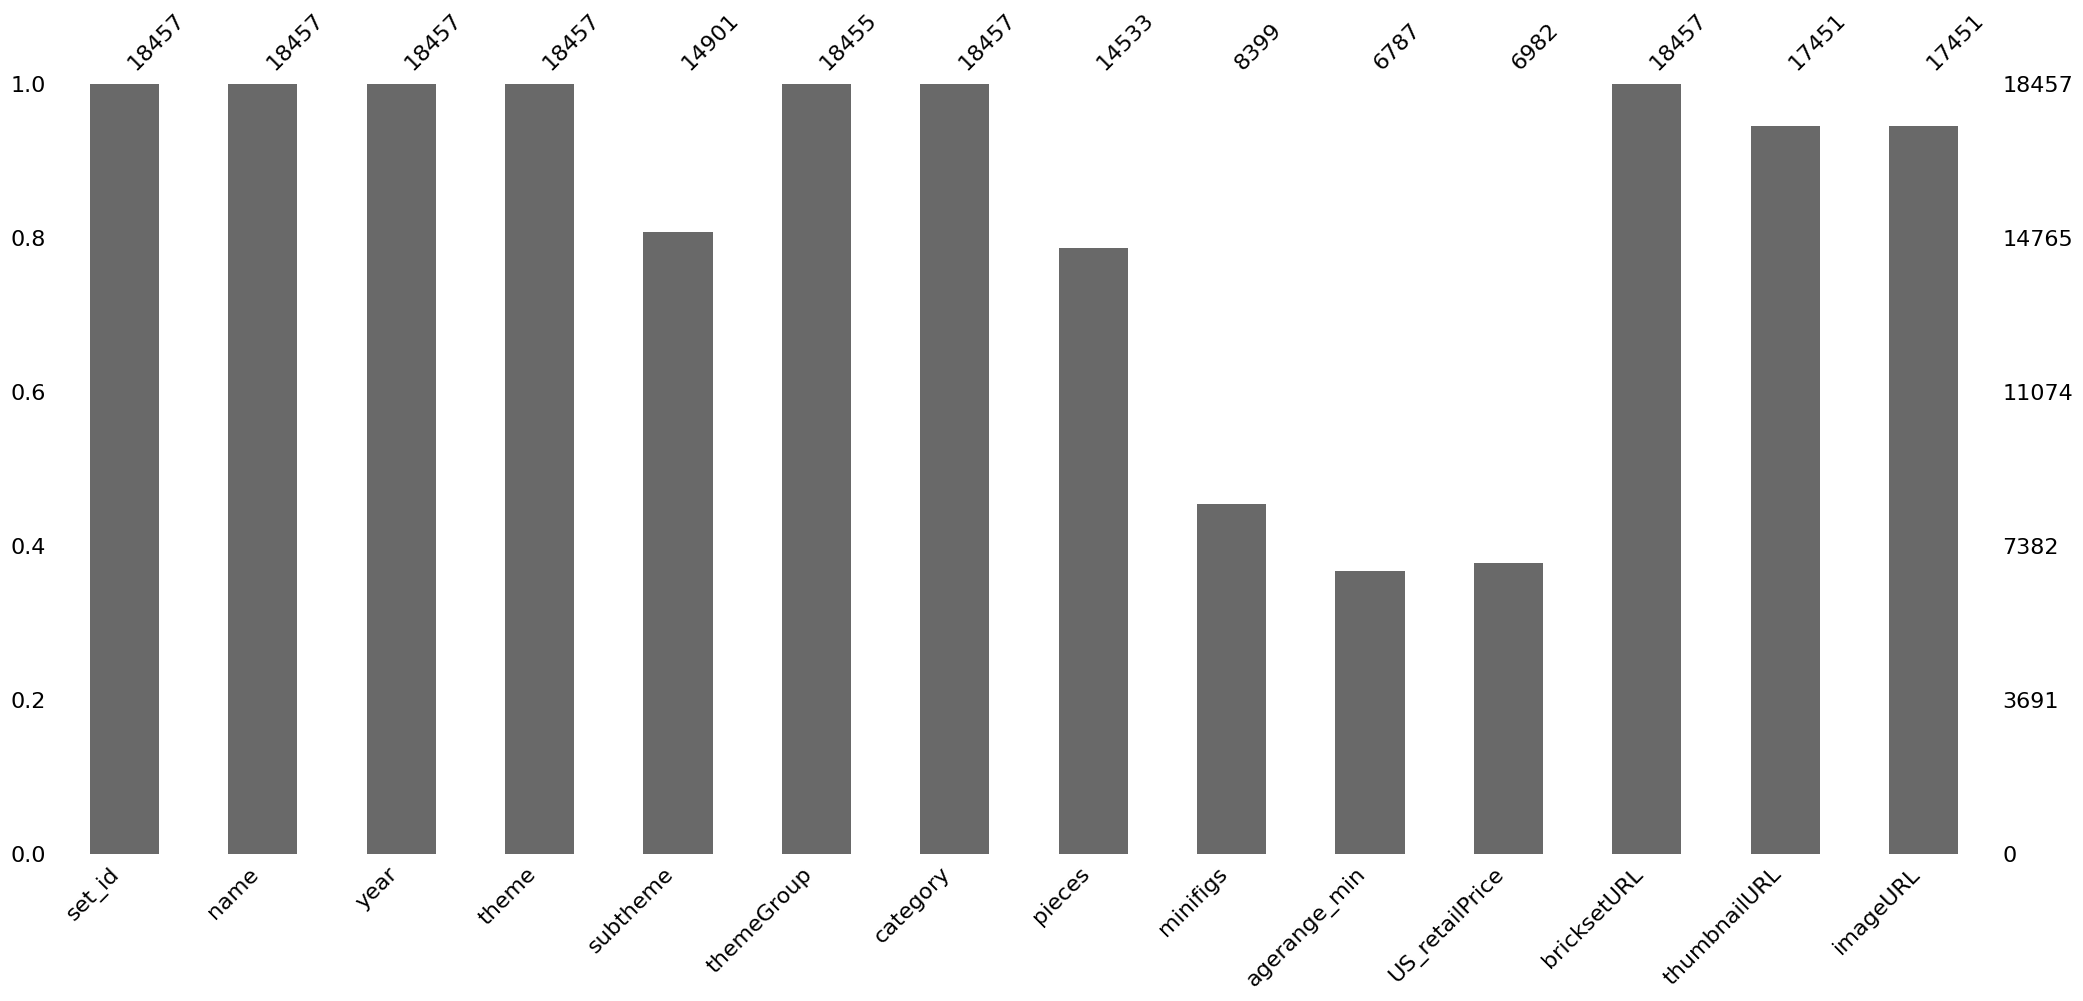

In [ ]:
msno.bar(lego_df)


<Axes: >

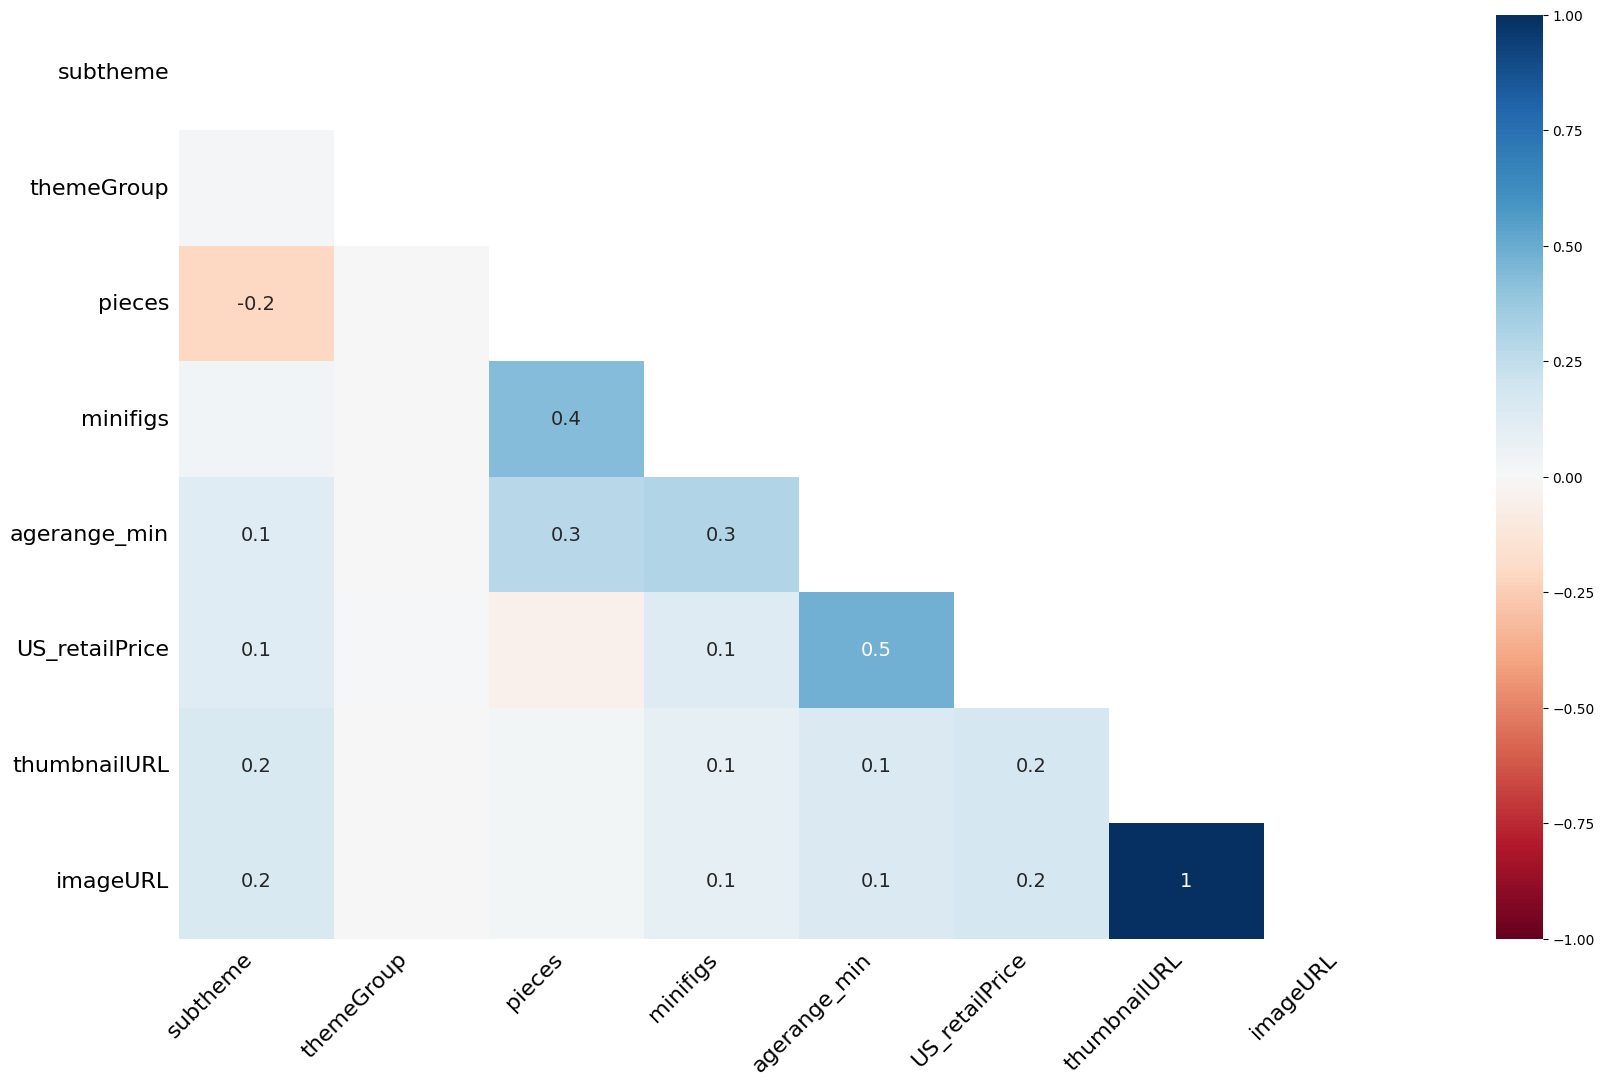

In [ ]:
msno.heatmap(lego_df)


Atividade: Criar uma coluna nova `price` e completar usando o modelo de redes neurais do Scikit-Learn (ANN), todos os conjuntos de leve devem ter preço.

Quais as colunas importantes para prever o preço??

### Heatmap de Correlação com Variáveis Categóricas e Numéricas (Nulos Removidos)

Para avaliar quais colunas são importantes para a predição do preço do conjunto de legos, foi feita a correção entre as variáveis na base de dados. Com algumas delas são categóricas, foi necessária realizar a sua transformação para valores numéricos. Optou-se pelo uso de `LabelEncoder` para realizar a codificação.

Além disso, foi desconsiderado os valores nulos presentes na base de dados.

Ao fim, foi produzido um heatmap para a exibição das correações.


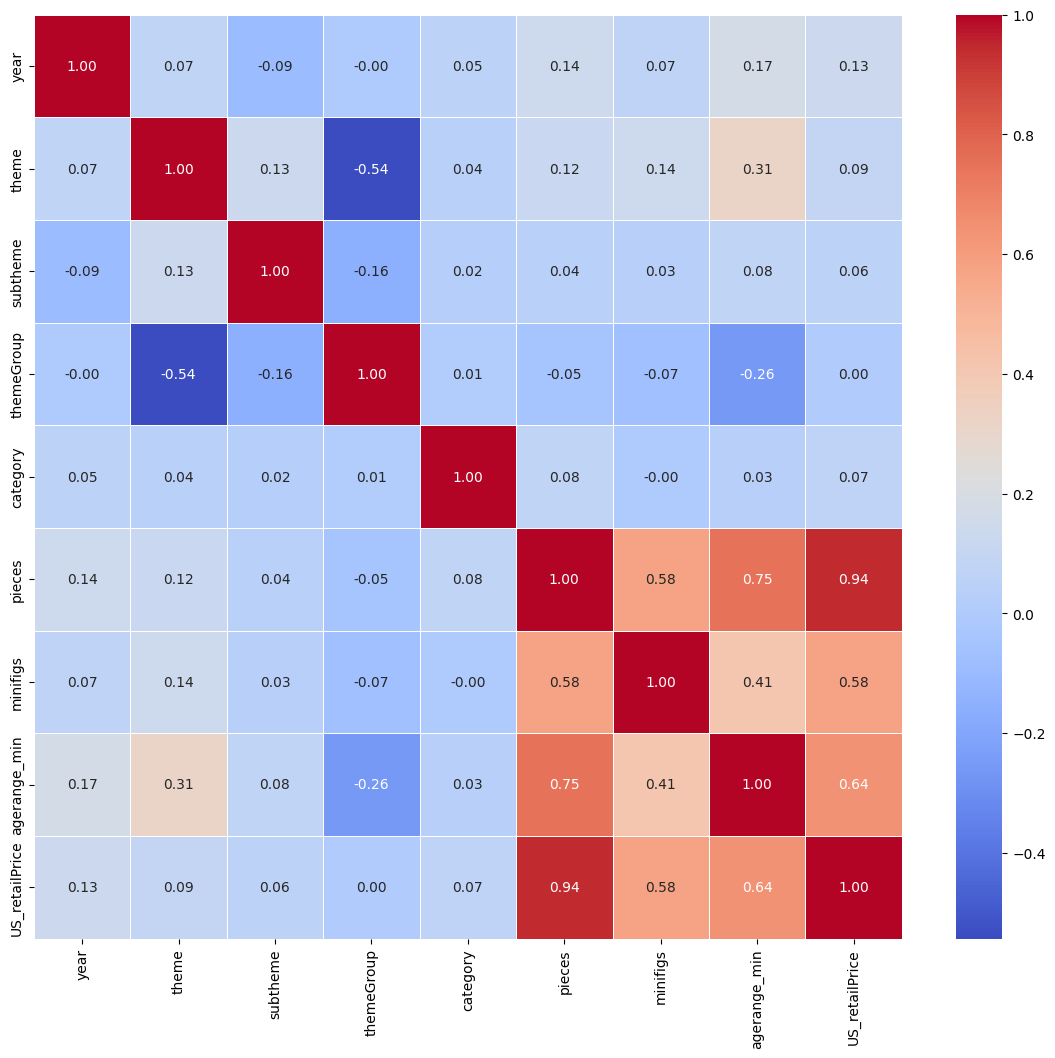

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_for_corr_all = lego_df.copy()

columns_to_correlate_all = [
    'year', 'theme', 'subtheme', 'themeGroup', 'category',
    'pieces', 'minifigs', 'agerange_min', 'US_retailPrice'
]

df_for_corr_all.dropna(subset=columns_to_correlate_all, inplace=True)

# Identificação das colunas categóricas para codificação
categorical_cols_all = [col for col in columns_to_correlate_all if df_for_corr_all[col].dtype == 'object']

for col in categorical_cols_all:
    le = LabelEncoder()
    df_for_corr_all[col] = le.fit_transform(df_for_corr_all[col])

# Construção da matriz de correlação para todas as variáveis
correlation_matrix_all = df_for_corr_all[columns_to_correlate_all].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.show()

# Tratamento do conjunto de dados
Nesta seção, haverá o tratamento da base de dados.
O tratamento é composto pela avaliação de outliers e da imputação de valores ausentes.


### 1. Tratamento de Outliers

A identificação de outliers nas colunas numéricas `pieces`, `minifigs`, `agerange_min` e `US_retailPrice` foi feita a partir o método do Intervalo Interquartil (IQR). Após isso é realizada a remoção dos valores encontrados

É feita uma cópia do dataframe para aplicar essas transformações e manter o dataframe original intacto.

In [ ]:
lego_df_cleaned = lego_df.copy()


numeric_cols_for_outliers = ['pieces', 'minifigs', 'agerange_min', 'US_retailPrice']

for col in numeric_cols_for_outliers:
    # Verifica que a coluna é numérica e trata NaNs temporariamente para cálculo do IQR
    if lego_df_cleaned[col].dtype == 'object':
        lego_df_cleaned[col] = pd.to_numeric(lego_df_cleaned[col], errors='coerce')

    q1 = lego_df_cleaned[col].quantile(0.25)
    q3 = lego_df_cleaned[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    lego_df_cleaned = lego_df_cleaned[
        (lego_df_cleaned[col] >= lower_bound) |
        (lego_df_cleaned[col].isnull()) | # Manter NaNs para imputação posterior
        (lego_df_cleaned[col] <= upper_bound)
    ]

print(f"DataFrame após remoção de outliers: {lego_df_cleaned.shape[0]} linhas")

DataFrame após remoção de outliers: 18457 linhas


### 2. Imputação de Dados Ausentes com a Moda

Para tratar os valores ausentes no dataframe, foi escolhida a imputação da moda para cada coluna.

In [ ]:
missing_cols = lego_df_cleaned.isnull().sum()
missing_cols = missing_cols[missing_cols > 0].index.tolist()

print("Colunas com valores ausentes antes da imputação:", missing_cols)

for col in missing_cols:
    mode_val = lego_df_cleaned[col].mode()[0]

    lego_df_cleaned[col] = lego_df_cleaned[col].fillna(mode_val)

print("Valores ausentes após imputação:")
display(lego_df_cleaned.isnull().sum())

Colunas com valores ausentes antes da imputação: ['subtheme', 'themeGroup', 'pieces', 'minifigs', 'agerange_min', 'US_retailPrice', 'thumbnailURL', 'imageURL']
Valores ausentes após imputação:


,0
set_id,0
name,0
year,0
theme,0
subtheme,0
themeGroup,0
category,0
pieces,0
minifigs,0
agerange_min,0


### Verificação da Limpeza

Apresentação das primeiras linhas do dataframe tratado e do resumo estatístico para verificar que os valores ausentes foram tratados e a estrutura está preservada.

In [ ]:
display(lego_df_cleaned.head())
display(lego_df_cleaned.info())

,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,Magazine Gift,Vintage,Normal,67.0,1.0,6.0,19.99,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,Magazine Gift,Vintage,Normal,109.0,1.0,6.0,19.99,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,Magazine Gift,Vintage,Normal,158.0,1.0,6.0,19.99,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,Magazine Gift,Vintage,Normal,233.0,1.0,6.0,19.99,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,6.0,1.0,6.0,19.99,https://brickset.com/sets/4-6,https://images.brickset.com/sets/small/30324-1...,https://images.brickset.com/sets/images/30324-...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18457 entries, 0 to 18456
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   set_id          18457 non-null  object 
 1   name            18457 non-null  object 
 2   year            18457 non-null  int64  
 3   theme           18457 non-null  object 
 4   subtheme        18457 non-null  object 
 5   themeGroup      18457 non-null  object 
 6   category        18457 non-null  object 
 7   pieces          18457 non-null  float64
 8   minifigs        18457 non-null  float64
 9   agerange_min    18457 non-null  float64
 10  US_retailPrice  18457 non-null  float64
 11  bricksetURL     18457 non-null  object 
 12  thumbnailURL    18457 non-null  object 
 13  imageURL        18457 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 2.0+ MB


None

### Previsão de Preços com MLP e Criação da Coluna 'prices'

Diante da problemática da criação da colunas `prices`, optou-se pelo uso do Multi-Layer Perceptron (MLP) do Scikit-learn para modelar o `US_retailPrice` com base nas variáveis `'agerange_min'`, `'minifigs'`, `'pieces'` e `'theme'`.

A escolha dessas variáveis foram feitas a partir da análise da correlação de `US_retailPrice` com as demais

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor

df_for_mlp = lego_df_cleaned.copy()

features_numeric = ['pieces', 'minifigs', 'agerange_min']
features_categorical = ['theme']
target = 'US_retailPrice'

# Escolonamento das colunas numéricas e aplicação do One-Hot Encoding em categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_categorical)
    ],
    remainder='passthrough'
)


X = df_for_mlp[features_numeric + features_categorical]
y = df_for_mlp[target]


X_processed = preprocessor.fit_transform(X)

print(f"Dimensões do X processado: {X_processed.shape}")
print(f"Dimensões do y: {y.shape}")

Dimensões do X processado: (18457, 157)
Dimensões do y: (18457,)


# Treinamento do modelo

In [ ]:
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 100),
                         activation='relu',
                         solver='adam',
                         max_iter=250,
                         random_state=42,
                         verbose=True)

mlp_model.fit(X_processed, y)

print("Treinamento do modelo MLP concluído.")

# Construção da coluna

In [ ]:
predicted_prices = mlp_model.predict(X_processed)

if len(predicted_prices) == len(lego_df_cleaned):
    lego_df_cleaned['prices'] = predicted_prices
else:
    print("O número de previsões não corresponde ao número de linhas no dataframe limpo.")
    lego_df_cleaned['prices'] = np.nan

print("DataFrame limpo com a nova coluna 'prices':")
display(lego_df_cleaned.head())

DataFrame limpo com a nova coluna 'prices':


,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL,prices
0,1-8,Small house set,1970,Minitalia,Magazine Gift,Vintage,Normal,67.0,1.0,6.0,19.99,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg,20.619709
1,2-8,Medium house set,1970,Minitalia,Magazine Gift,Vintage,Normal,109.0,1.0,6.0,19.99,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg,20.533012
2,3-6,Medium house set,1970,Minitalia,Magazine Gift,Vintage,Normal,158.0,1.0,6.0,19.99,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg,20.490464
3,4-4,Large house set,1970,Minitalia,Magazine Gift,Vintage,Normal,233.0,1.0,6.0,19.99,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg,20.949717
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,6.0,1.0,6.0,19.99,https://brickset.com/sets/4-6,https://images.brickset.com/sets/small/30324-1...,https://images.brickset.com/sets/images/30324-...,19.880286


### Comparação entre Preços Reais e Preços Previstos (MLP)

Para avaliar a performance do modelo MLP, foi observada a relação entre o `US_retailPrice` e a nova coluna `prices` em um gráfico de dispersão. Uma linha de 45 graus foi adicionada para indicar onde os valores previstos seriam exatamente iguais aos reais.

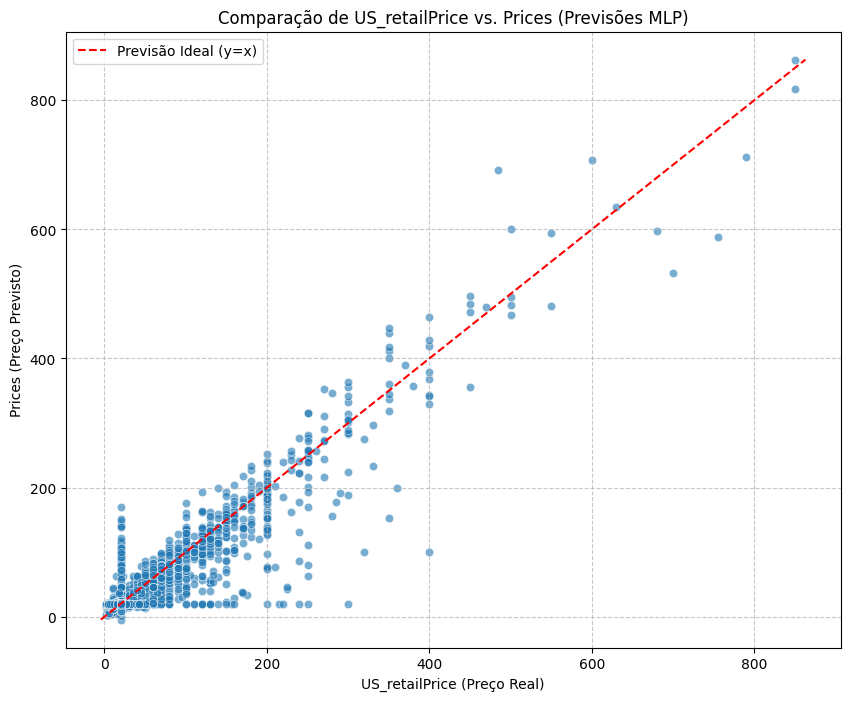

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='US_retailPrice', y='prices', data=lego_df_cleaned, alpha=0.6)

min_val = min(lego_df_cleaned['US_retailPrice'].min(), lego_df_cleaned['prices'].min())
max_val = max(lego_df_cleaned['US_retailPrice'].max(), lego_df_cleaned['prices'].max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Previsão Ideal (y=x)')

plt.title('Comparação de US_retailPrice vs. Prices (Previsões MLP)')
plt.xlabel('US_retailPrice (Preço Real)')
plt.ylabel('Prices (Preço Previsto)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comparação entre US_retailPrice Original e Prices Previstos

É feita a comparação nos conjuntos que já tinham um `US_retailPrice` na base de dados originalmente com os valores de `prices` previstos pelo modelo. Isso permite observar quanto o modelo está se ajustando aos dados existentes. Foi utilizado o `set_id` para a união.

In [ ]:
original_prices_df = lego_df[lego_df['US_retailPrice'].notnull()][['set_id', 'US_retailPrice']]

predicted_prices_df = lego_df_cleaned[['set_id', 'prices']]

comparison_df = pd.merge(original_prices_df, predicted_prices_df, on='set_id', how='inner')

print("Primeiras linhas do DataFrame de comparação:")
display(comparison_df.head())

print(f"Total de conjuntos com preço original e previsto para comparação: {len(comparison_df)}")

Primeiras linhas do DataFrame de comparação:


,set_id,US_retailPrice,prices
0,4515-1,12.99,20.323690
1,4520-1,12.99,20.323690
2,4531-1,27.99,20.322314
3,4548-1,41.99,20.320250
4,2304-1,14.99,11.352239


Total de conjuntos com preço original e previsto para comparação: 6982


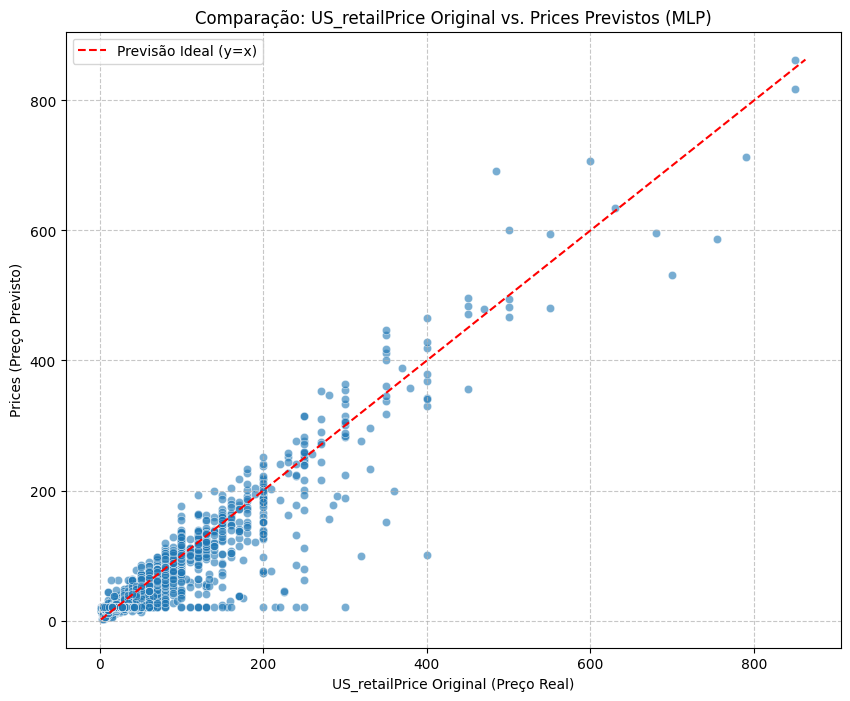

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='US_retailPrice', y='prices', data=comparison_df, alpha=0.6)

min_val_comp = min(comparison_df['US_retailPrice'].min(), comparison_df['prices'].min())
max_val_comp = max(comparison_df['US_retailPrice'].max(), comparison_df['prices'].max())

plt.plot([min_val_comp, max_val_comp], [min_val_comp, max_val_comp], color='red', linestyle='--', label='Previsão Ideal (y=x)')

plt.title('Comparação: US_retailPrice Original vs. Prices Previstos (MLP)')
plt.xlabel('US_retailPrice Original (Preço Real)')
plt.ylabel('Prices (Preço Previsto)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comparação de Quantidade de Peças, Minifigures com os preços reais e preços estimados

De forma complementar, realiza-se a comparação entre a quantidade de peças e o preço real dos produtos, bem como entre a quantidade de minifigures e o preço real. Essa observação busca avaliar em que medida essas variáveis contribuíram para a predição dos preços pelo modelo.
A comparação envolvendo os preços reais foram baseadas na base de dados original, enquanto a comparação com os preços estimandos foram baseados na base de dados tratada.

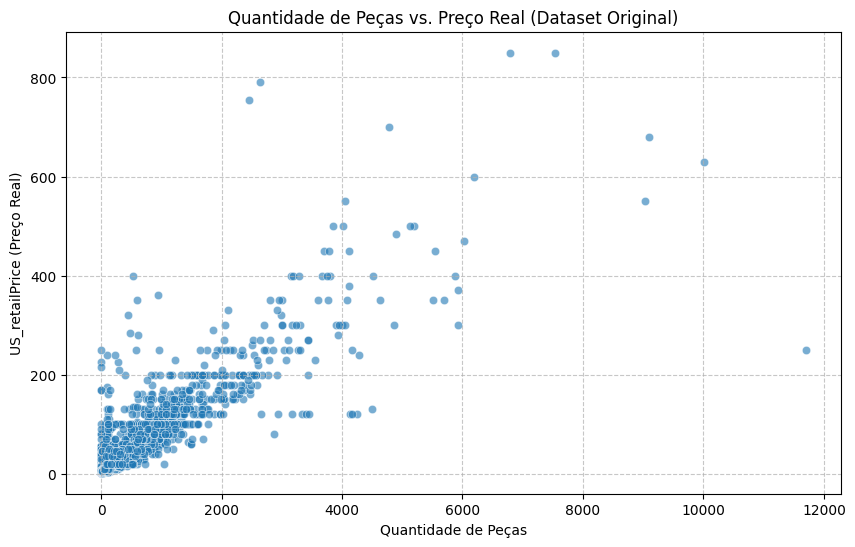

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pieces', y='US_retailPrice', data=lego_df, alpha=0.6)
plt.title('Quantidade de Peças vs. Preço Real (Dataset Original)')
plt.xlabel('Quantidade de Peças')
plt.ylabel('US_retailPrice (Preço Real)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

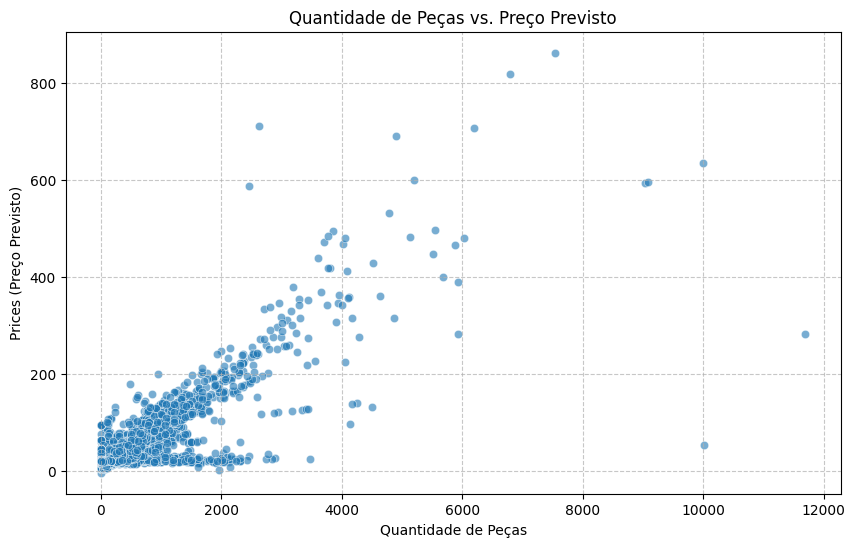

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pieces', y='prices', data=lego_df_cleaned, alpha=0.6)
plt.title('Quantidade de Peças vs. Preço Previsto')
plt.xlabel('Quantidade de Peças')
plt.ylabel('Prices (Preço Previsto)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

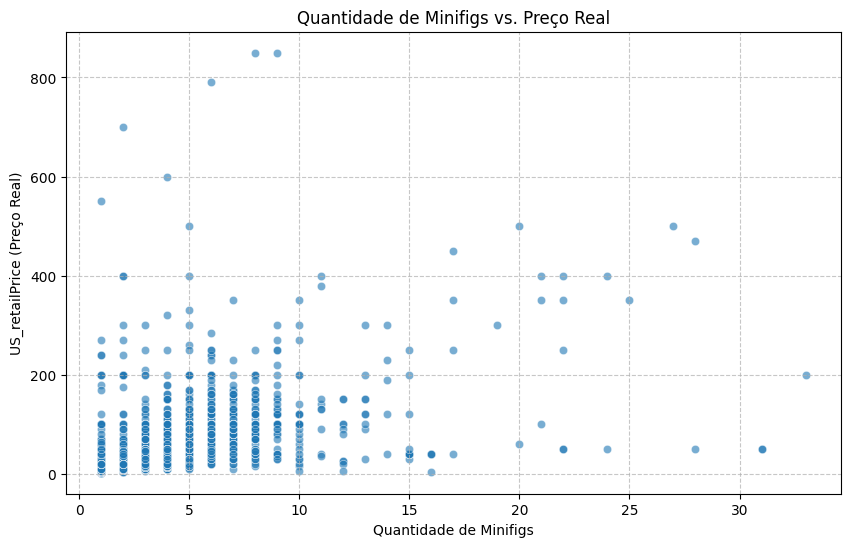

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='minifigs', y='US_retailPrice', data=lego_df, alpha=0.6)
plt.title('Quantidade de Minifigs vs. Preço Real')
plt.xlabel('Quantidade de Minifigs')
plt.ylabel('US_retailPrice (Preço Real)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

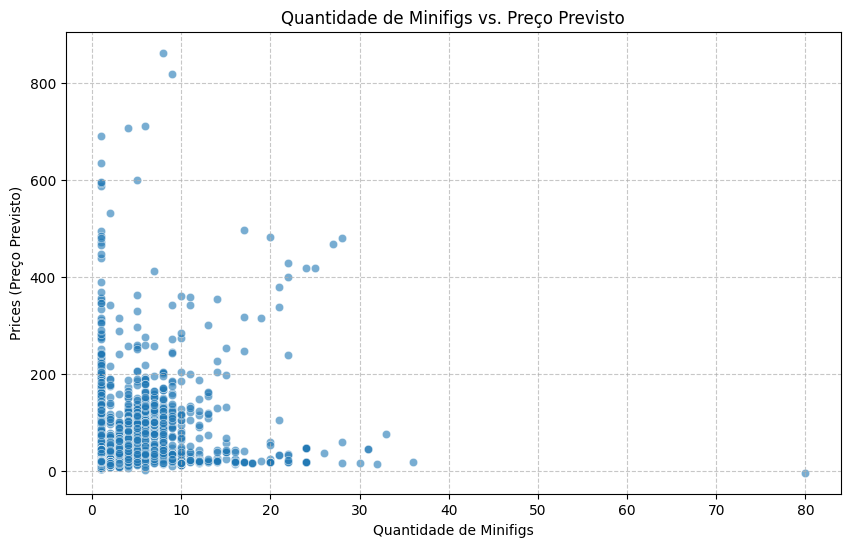

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='minifigs', y='prices', data=lego_df_cleaned, alpha=0.6)
plt.title('Quantidade de Minifigs vs. Preço Previsto')
plt.xlabel('Quantidade de Minifigs')
plt.ylabel('Prices (Preço Previsto)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Avaliação do modelo com métricas
Nesta seção, são calculadas as métricas MAE, MSE, RMSE e R², a fim de avaliar o desempenho e a capacidade preditiva do modelo.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = comparison_df['US_retailPrice']
y_pred = comparison_df['prices']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

metrics_df = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Valor': [mae, mse, rmse, r2]
})

print("Métricas de Avaliação do Modelo MLP:")
display(metrics_df)

Métricas de Avaliação do Modelo MLP:


,Métrica,Valor
0,MAE,9.455101
1,MSE,338.330726
2,RMSE,18.393769
3,R2 Score,0.885585


Os resultados obtidos foram um R² de 0,886, um MAE de 9,455, um MSE de 338,331 e um RMSE de 18,394. O R² de 0,886 indica que o modelo conseguiu explicar aproximadamente 88,6% da variabilidade observada na variável de interesse. Entretanto, esse resultado deve ser interpretado com cautela, pois o modelo foi avaliado sobre os mesmos dados utilizados durante seu treinamento. Dessa forma, o valor elevado do R² pode representar uma estimativa otimista do desempenho, já que não é possível verificar adequadamente como o modelo se comportaria diante de dados novos. O MAE de 9,455 indica que, em média, as previsões apresentaram uma diferença absoluta de aproximadamente 9,455 unidades em relação aos valores reais. Já o MSE de 338,331 e o RMSE de 18,394 indicam a magnitude dos erros considerando uma penalização maior para erros elevados. Portanto, embora os resultados indiquem um bom ajuste aos dados utilizados, eles não permitem avaliar de forma confiável a capacidade de generalização do modelo.

## Novo Treinamento e Avaliação: Separação Treino/Teste e Limpeza Apenas no Treino

Nesta seção, é refeito o processo de modelagem, mas com uma abordagem mais robusta para evitar *data leakage*:

1.  **Divisão dos Dados**: Separar o `lego_df` original em conjuntos de treino e teste antes de qualquer tratamento.
2.  **Tratamento no Treino**: Realizar a remoção de outliers e a imputação de valores ausentes somente no conjunto de treino.
3.  **Aplicação no Teste**: Utilizar os parâmetros de limpeza (limites IQR, modas) produzidos no treino para tratar o conjunto de teste.
4.  **Treinamento e Avaliação**: Treinar o modelo no conjunto de treino limpo e avaliá-lo no conjunto de teste limpo.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_full = lego_df.drop(columns=['US_retailPrice'])
y_full = lego_df['US_retailPrice']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

train_data_raw = X_train_raw.copy()
train_data_raw['US_retailPrice'] = y_train_raw

test_data_raw = X_test_raw.copy()
test_data_raw['US_retailPrice'] = y_test_raw

train_data_raw = train_data_raw.reset_index(drop=True)
test_data_raw = test_data_raw.reset_index(drop=True)

print(f"Shape do train_data_raw (treino antes da limpeza): {train_data_raw.shape}")
print(f"Shape do test_data_raw (teste antes da limpeza): {test_data_raw.shape}")

Shape do train_data_raw (treino antes da limpeza): (14765, 14)
Shape do test_data_raw (teste antes da limpeza): (3692, 14)


### Tratamento de Outliers

Realização dos cálculos os limites do Intervalo Interquartil (IQR) para as colunas numéricas de interesse apenas no `train_data_raw` e, em seguida, remoção das linhas que contêm outliers com base nesses limites.

In [ ]:
train_data_cleaned = train_data_raw.copy()

numeric_cols_for_outliers = ['pieces', 'minifigs', 'agerange_min', 'US_retailPrice']

iqr_bounds = {}
for col in numeric_cols_for_outliers:
    if col in train_data_cleaned.columns and train_data_cleaned[col].dtype == 'object':
        train_data_cleaned[col] = pd.to_numeric(train_data_cleaned[col], errors='coerce')

    q1 = train_data_cleaned[col].quantile(0.25)
    q3 = train_data_cleaned[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    iqr_bounds[col] = (lower_bound, upper_bound)

initial_train_rows = train_data_cleaned.shape[0]
for col, (lower, upper) in iqr_bounds.items():
    train_data_cleaned = train_data_cleaned[
        (train_data_cleaned[col] >= lower) |
        (train_data_cleaned[col].isnull()) |
        (train_data_cleaned[col] <= upper)
    ]

train_data_cleaned = train_data_cleaned.reset_index(drop=True)

print(f"Linhas removidas do conjunto de treino devido a outliers: {initial_train_rows - train_data_cleaned.shape[0]}")
print(f"Shape do treino após remoção de outliers: {train_data_cleaned.shape}")

Linhas removidas do conjunto de treino devido a outliers: 0
Shape do treino após remoção de outliers: (14765, 14)


### Imputação de Valores Ausentes com a Moda

As modas para cada coluna com valores ausentes serão calculadas apenas no conjunto de treino limpo e, em seguida, usadas para preencher os NaNs no treino.

In [ ]:
imputation_modes = {}
for col in train_data_cleaned.columns:
    if train_data_cleaned[col].isnull().any():
        if train_data_cleaned[col].dtype == 'object':
            try:
                mode_val = pd.to_numeric(train_data_cleaned[col], errors='coerce').mode()[0]
            except:
                mode_val = train_data_cleaned[col].mode()[0]
        else:
            mode_val = train_data_cleaned[col].mode()[0]
        imputation_modes[col] = mode_val

for col, mode_val in imputation_modes.items():
    train_data_cleaned[col] = train_data_cleaned[col].fillna(mode_val)

print(f"Shape do treino após imputação: {train_data_cleaned.shape}")
print("Verificação de valores ausentes no treino após limpeza:")
display(train_data_cleaned.isnull().sum().sum())

Shape do treino após imputação: (14765, 14)
Verificação de valores ausentes no treino após limpeza:


np.int64(0)

### Aplicação do Tratamento de Dados no Conjunto de Teste

Aplicação das transformações no `test_data_raw` utilizando os parâmetros produzidos do conjunto de treino. Isso garante que o conjunto de teste seja processado de forma consistente sem vazar informações do treino.

In [ ]:
test_data_cleaned = test_data_raw.copy()

for col in numeric_cols_for_outliers:
    if col in test_data_cleaned.columns and test_data_cleaned[col].dtype == 'object':
        test_data_cleaned[col] = pd.to_numeric(test_data_cleaned[col], errors='coerce')

initial_test_rows = test_data_cleaned.shape[0]
for col, (lower, upper) in iqr_bounds.items():
    if col in test_data_cleaned.columns:
        test_data_cleaned = test_data_cleaned[
            (test_data_cleaned[col] >= lower) |
            (test_data_cleaned[col].isnull()) |
            (test_data_cleaned[col] <= upper)
        ]

# Reseta índice após remover linhas
test_data_cleaned = test_data_cleaned.reset_index(drop=True)

print(f"Linhas removidas do conjunto de teste (baseado nos limites de treino): {initial_test_rows - test_data_cleaned.shape[0]}")
print(f"Shape do teste após remoção de outliers: {test_data_cleaned.shape}")


for col, mode_val in imputation_modes.items():
    if col in test_data_cleaned.columns:
        test_data_cleaned[col] = test_data_cleaned[col].fillna(mode_val)

print(f"Shape do teste após imputação: {test_data_cleaned.shape}")
print("Verificação de valores ausentes no teste após limpeza:")
display(test_data_cleaned.isnull().sum().sum())

Linhas removidas do conjunto de teste (baseado nos limites de treino): 0
Shape do teste após remoção de outliers: (3692, 14)
Shape do teste após imputação: (3692, 14)
Verificação de valores ausentes no teste após limpeza:


np.int64(0)

In [ ]:
X_train_final = train_data_cleaned.drop(columns=['US_retailPrice'])
y_train_final = train_data_cleaned['US_retailPrice']
X_test_final = test_data_cleaned.drop(columns=['US_retailPrice'])
y_test_final = test_data_cleaned['US_retailPrice']

print(f"Shape final de X_train_final: {X_train_final.shape}")
print(f"Shape final de y_train_final: {y_train_final.shape}")
print(f"Shape final de X_test_final: {X_test_final.shape}")
print(f"Shape final de y_test_final: {y_test_final.shape}")

Shape final de X_train_final: (14765, 13)
Shape final de y_train_final: (14765,)
Shape final de X_test_final: (3692, 13)
Shape final de y_test_final: (3692,)


### Treinamento e Previsão com MLP

In [ ]:
features_numeric = ['pieces', 'minifigs', 'agerange_min']
features_categorical = ['theme']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_categorical)
    ],
    remainder='drop'
)

X_train_final_selected = X_train_final[features_numeric + features_categorical]
X_test_final_selected = X_test_final[features_numeric + features_categorical]

X_train_processed = preprocessor.fit_transform(X_train_final_selected)

X_test_processed = preprocessor.transform(X_test_final_selected)

print(f"Dimensões do X_train_processed: {X_train_processed.shape}")
print(f"Dimensões do X_test_processed: {X_test_processed.shape}")

Dimensões do X_train_processed: (14765, 156)
Dimensões do X_test_processed: (3692, 156)


In [ ]:

mlp_model_new = MLPRegressor(hidden_layer_sizes=(100, 100),
                             activation='relu',
                             solver='adam',
                             max_iter=250,
                             random_state=42,
                             verbose=True)

mlp_model_new.fit(X_train_processed, y_train_final)

print("Treinamento do novo modelo MLP concluído.")

In [ ]:
y_pred_test = mlp_model_new.predict(X_test_processed)

test_data_cleaned_with_prices = test_data_cleaned.copy()
test_data_cleaned_with_prices['prices_predicted'] = y_pred_test

print("Previsões adicionadas ao conjunto de teste.")
display(test_data_cleaned_with_prices.head())

Previsões adicionadas ao conjunto de teste.


,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,bricksetURL,thumbnailURL,imageURL,US_retailPrice,prices_predicted
0,5725-1,LEGO Alpha Team,2000,Gear,Video Games/Game Boy Color,Miscellaneous,Gear,6.0,1.0,6.0,https://brickset.com/sets/5725-1,https://images.brickset.com/sets/small/5725-1.jpg,https://images.brickset.com/sets/images/5725-1...,19.99,19.370526
1,1188-1,Fire Formula,1999,Town,Extreme Team,Modern day,Normal,38.0,1.0,6.0,https://brickset.com/sets/1188-1,https://images.brickset.com/sets/small/1188-1.jpg,https://images.brickset.com/sets/images/1188-1...,19.99,19.883704
2,41004-1,Rehearsal Stage,2013,Friends,Music,Modern day,Normal,198.0,1.0,6.0,https://brickset.com/sets/41004-1,https://images.brickset.com/sets/small/41004-1...,https://images.brickset.com/sets/images/41004-...,19.99,18.910874
3,854021-1,Creative Bag Charm,2020,Gear,Key Chains/Brick,Miscellaneous,Gear,6.0,1.0,6.0,https://brickset.com/sets/854021-1,https://images.brickset.com/sets/small/854021-...,https://images.brickset.com/sets/images/854021...,6.99,19.370526
4,4151849-1,Bionicle Trading Card Game 1: Onua & Lewa,2001,Gear,Trading/Playing cards,Miscellaneous,Gear,6.0,1.0,6.0,https://brickset.com/sets/4151849-1,https://images.brickset.com/sets/small/4151849...,https://images.brickset.com/sets/images/415184...,19.99,19.370526


###Preços Reais vs. Preços Previstos (Conjunto de Teste)

Similarmente à observação anterior com *data leakage*, é feito um gráfico de dispersão para comparar os preços reais e previstos no conjunto de teste para observar performance do modelo.

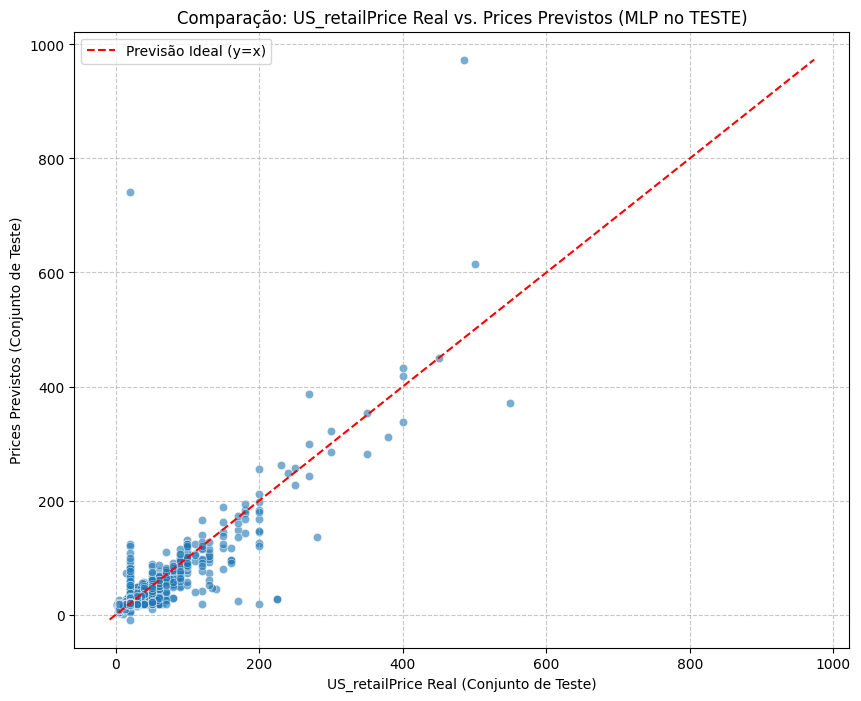

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_final, y=y_pred_test, alpha=0.6)

min_val_test = min(y_test_final.min(), y_pred_test.min())
max_val_test = max(y_test_final.max(), y_pred_test.max())

plt.plot([min_val_test, max_val_test], [min_val_test, max_val_test], color='red', linestyle='--', label='Previsão Ideal (y=x)')

plt.title('Comparação: US_retailPrice Real vs. Prices Previstos (MLP no TESTE)')
plt.xlabel('US_retailPrice Real (Conjunto de Teste)')
plt.ylabel('Prices Previstos (Conjunto de Teste)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

###Comparação de Pieces e Minifigs com Preços Reais e Previstos no Conjunto de Teste
Como complemento à observação anterior, que focou na comparação entre os preços reais e previstos, esta etapa busca avaliar a relação entre as variáveis pieces e minifigs e os respectivos preços. Para isso, são comparados os preços reais e os preços previstos pelo modelo no conjunto de teste, permitindo analisar como essas características se relacionam com as estimativas realizadas pelo modelo.

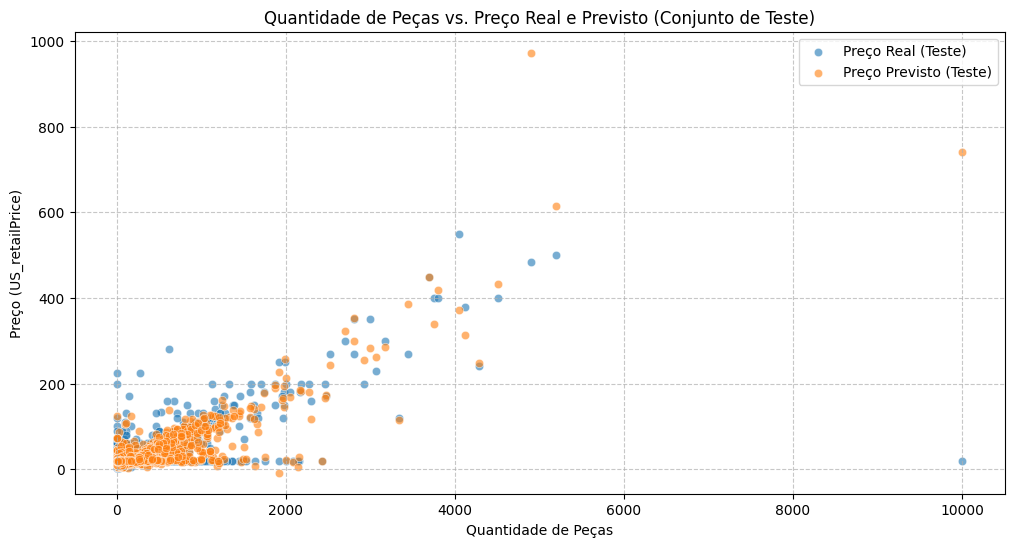

In [ ]:
test_data_plot = X_test_final.copy()
test_data_plot['US_retailPrice_Real'] = y_test_final
test_data_plot['US_retailPrice_Predicted'] = y_pred_test

plt.figure(figsize=(12, 6))
sns.scatterplot(x='pieces', y='US_retailPrice_Real', data=test_data_plot, alpha=0.6, label='Preço Real (Teste)')
sns.scatterplot(x='pieces', y='US_retailPrice_Predicted', data=test_data_plot, alpha=0.6, label='Preço Previsto (Teste)')

plt.title('Quantidade de Peças vs. Preço Real e Previsto (Conjunto de Teste)')
plt.xlabel('Quantidade de Peças')
plt.ylabel('Preço (US_retailPrice)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

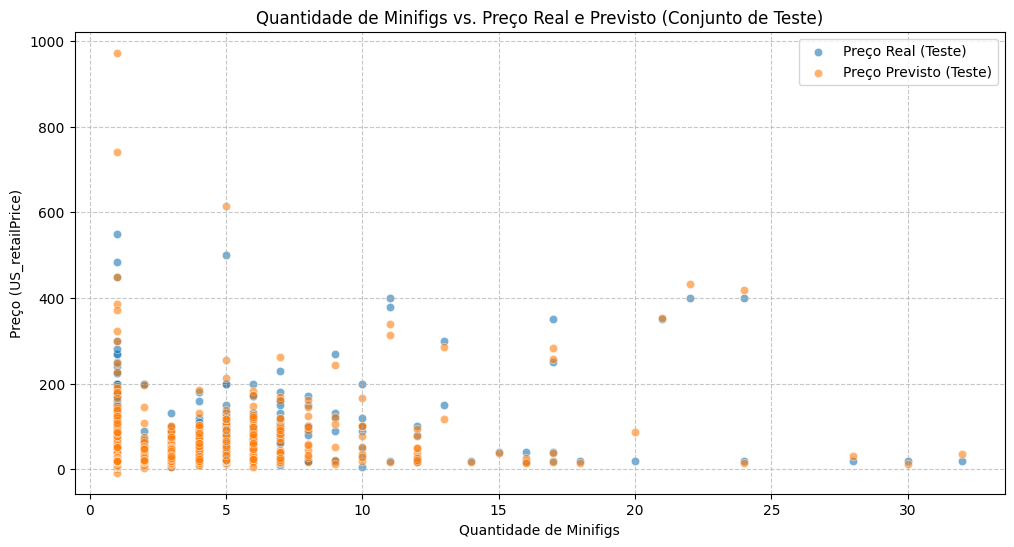

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='minifigs', y='US_retailPrice_Real', data=test_data_plot, alpha=0.6, label='Preço Real (Teste)')
sns.scatterplot(x='minifigs', y='US_retailPrice_Predicted', data=test_data_plot, alpha=0.6, label='Preço Previsto (Teste)')

plt.title('Quantidade de Minifigs vs. Preço Real e Previsto (Conjunto de Teste)')
plt.xlabel('Quantidade de Minifigs')
plt.ylabel('Preço (US_retailPrice)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Avaliação do Novo Modelo no Conjunto de Teste
Realização do cálculo das métricas de regressão (MAE, MSE, RMSE, R2 Score) para avaliar o desempenho do modelo no conjunto de teste.

In [ ]:
mae_test = mean_absolute_error(y_test_final, y_pred_test)
mse_test = mean_squared_error(y_test_final, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test_final, y_pred_test)

metrics_df_test = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Valor': [mae_test, mse_test, rmse_test, r2_test]
})

print("Métricas de Avaliação do Novo Modelo MLP:")
display(metrics_df_test)

Métricas de Avaliação do Novo Modelo MLP:


,Métrica,Valor
0,MAE,5.699395
1,MSE,373.590009
2,RMSE,19.328477
3,R2 Score,0.664693


Os resultados obtidos foram um R² de 0,665, um MAE de 5,699, um MSE de 373,590 e um RMSE de 19,328. O R² de 0,665 indica que o modelo conseguiu explicar aproximadamente 66,5% da variabilidade dos valores no conjunto de teste. Embora esse valor seja inferior ao obtido no primeiro caso, ele representa uma avaliação mais adequada da capacidade de generalização, pois foi calculado sobre dados não utilizados no treinamento. O MAE de 5,699 indica que, em média, as previsões diferiram dos valores reais em aproximadamente 5,699 unidades, apresentando um erro absoluto médio inferior ao observado no primeiro caso. Por outro lado, o MSE e o RMSE foram ligeiramente superiores, com valores de 373,590 e 19,328, respectivamente. Essa diferença indica que, apesar de o erro absoluto médio ter sido menor, algumas previsões podem ter apresentado erros mais elevados, os quais recebem maior peso nessas métricas devido à aplicação do erro ao quadrado. Assim, os resultados do segundo caso permitem uma avaliação mais realista do comportamento do modelo diante de dados que não foram utilizados durante seu treinamento.